# Metropolis-Hastings algorithm

In [46]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import trange

In [47]:
data_full = pd.read_table("data/Pantheon_SH0ES.dat", delimiter=" ")
print(len(data_full))
data_full.head()

1701


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


In [48]:
cov_full = np.loadtxt("data/Pantheon_SH0ES_STAT_SYS.cov", skiprows=1).reshape(len(data_full), len(data_full))

In [49]:
mask = ((data_full["IS_CALIBRATOR"] == 1) | (data_full["USED_IN_SH0ES_HF"] == 1)).to_numpy()
print(f"{mask.sum()} / {len(mask)}")

354 / 1701


In [50]:
data = data_full[mask]
cov = cov_full[np.ix_(mask, mask)]

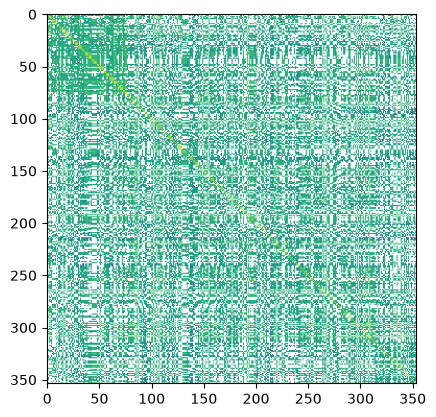

In [51]:
plt.imshow(cov, norm="log")

In [52]:
print(data.columns)
data.head()

Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='str')


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
5,1981B,50,0.00317,0.00084,0.00350,0.00001,0.00236,0.00001,11.54160,0.613941,...,0.2973,41,43.2260,0.376420,0.0732,0.5763,0.0206,0.007,1.0,0.013


In [53]:
is_calibrator = data["IS_CALIBRATOR"].to_numpy(dtype=bool)
is_hf = ~is_calibrator


def m_b_calibrator(M_B: float) -> np.ndarray:
    return M_B + data.loc[is_calibrator]["CEPH_DIST"]

In [54]:
from astropy import units as u
from astropy.cosmology import WMAP9 as cosmo

D_L_ref = np.array([cosmo.luminosity_distance(z).to(u.Mpc).value for z in data.loc[is_hf]["zHD"]])

In [55]:
def m_b_hf(H0: float, M_B: float) -> np.ndarray:
    D_L = D_L_ref * (cosmo.H0.value / H0)
    return 25 + 5 * np.log10(D_L) + M_B

In [56]:
inv_cov = np.linalg.inv(cov)

In [57]:
def loglike(H0: float, M_B: float) -> float:
    # print(H0, M_B)
    residuals_calibrator = m_b_calibrator(M_B) - data.loc[is_calibrator, "m_b_corr"].to_numpy()
    residuals_hf = m_b_hf(H0, M_B) - data.loc[is_hf, "m_b_corr"].to_numpy()
    # HACK: this implicitly assumes calibrator and HF samples are disjoint
    redisuals_total = np.concatenate([residuals_calibrator, residuals_hf])
    return -0.5 * redisuals_total.T @ inv_cov @ redisuals_total

# Max likelihood analysis

In [85]:
from scipy import optimize

opt_res = optimize.minimize(
    fun=lambda theta: -loglike(*theta), x0=np.array([70, -19.3]), bounds=[(0, None), (None, None)]
)

opt_res

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 150.17466084893192
        x: [ 7.358e+01 -1.925e+01]
      nit: 6
      jac: [ 1.137e-05 -1.077e-03]
     nfev: 39
     njev: 13
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

# Bayesian analysis with MCMC

In [59]:
def logpost(H0: float, M_B: float) -> float:
    if H0 <= 0:
        return -np.inf
    return loglike(H0, M_B)

In [91]:
import scipy.stats

propsal_dist = scipy.stats.multivariate_normal(mean=np.zeros(2), cov=np.diag([0.5, 0.01]))


def metropolis_hastings_step(theta: np.ndarray):
    # print(theta)
    for try_ in range(1000):
        proposal = propsal_dist.rvs() + theta
        acceptance_prob = min(1, np.exp(logpost(*proposal) - logpost(*theta)))
        if scipy.stats.uniform.rvs() < acceptance_prob:
            return proposal, try_
    raise RuntimeError("failed to accept a proposal after 1000 attempts")

In [105]:
def metropolis_hastings(theta0=np.array([70.0, -19.3]), n_steps: int = 5000):
    chain = []
    tries = []
    theta = theta0
    for _ in trange(n_steps):
        chain.append(theta)
        theta, try_ = metropolis_hastings_step(theta)
        tries.append(try_)
    chain.append(theta)
    return chain, tries

In [106]:
chain, tries = metropolis_hastings()

100%|██████████| 5000/5000 [01:05<00:00, 76.12it/s] 


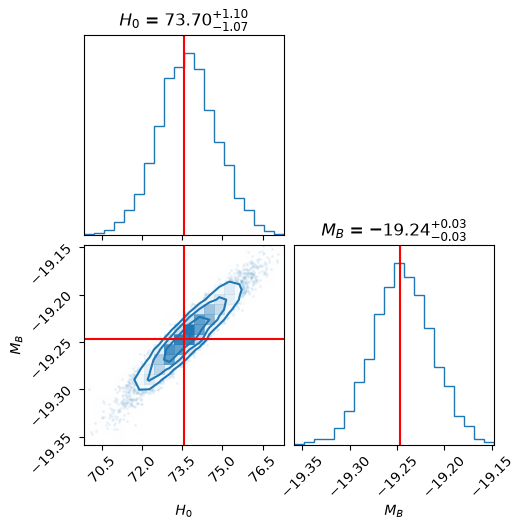

In [114]:
import corner

labels = ["$H_0$", "$M_B$"]

fig = corner.corner(
    np.array(chain),
    labels=labels,
    show_titles=True,
    color="tab:blue",
)
corner.overplot_lines(fig, opt_res.x, color="r")

In [111]:
chain2, tries2 = metropolis_hastings(theta0=np.array([30.0, -15.0]))

  0%|          | 0/5000 [00:00<?, ?it/s]/var/folders/pt/5p7r1p1j49n8f_88l1j7jtwc0000gn/T/ipykernel_11530/2204074237.py:11: RuntimeWarning: overflow encountered in exp
  acceptance_prob = min(1, np.exp(logpost(*proposal) - logpost(*theta)))
100%|██████████| 5000/5000 [01:00<00:00, 82.19it/s] 


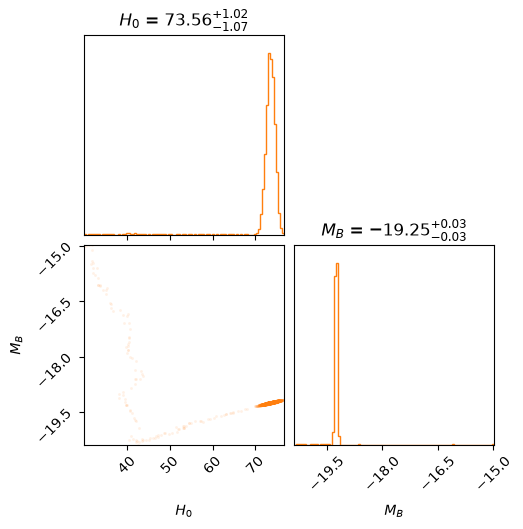

In [117]:
fig = corner.corner(
    np.array(chain2),
    labels=labels,
    show_titles=True,
    color="tab:orange",
    plot_contours=False,
    plot_density=False,
    bins=100,
)

Text(0.5, 0, 'Step')

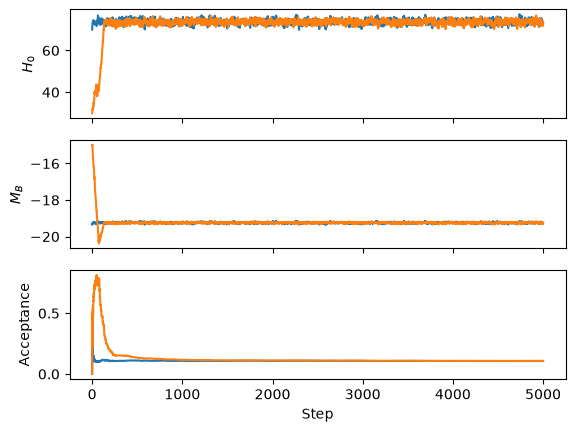

In [119]:
fig, ax = plt.subplots(nrows=len(chain[0]) + 1, ncols=1, sharex=True)

for chain_ in (chain, chain2):
    for i, label in zip(range(len(chain_[0])), labels):
        ax[i].plot([theta[i] for theta in chain_])
        ax[i].set_ylabel(label)

for tries_ in (tries, tries2):
    t = np.array([1, *tries_])
    tries_cumulative = np.cumsum(t)
    ax[-1].plot(np.arange(len(tries_cumulative)) / tries_cumulative)

# ax[-1].set_yscale("log")
ax[-1].set_ylabel("Acceptance")

ax[-1].set_xlabel("Step")